# Conjugate and nonparametric Bayesian inference

How conjugate priors turn fitting into posterior inference, why a NormalGamma prior regularizes a small sample, and how Dirichlet-process mixtures infer their own complexity. For the bare `mixle.stats` API, see the bayesian_distributions tutorial.


## Conjugacy and posterior concentration

Definition (conjugacy). A prior is conjugate to a likelihood when the posterior stays in the prior's
family, so Bayes' rule reduces to a hyperparameter update. For a Bernoulli likelihood the Beta is
conjugate: $\mathrm{Beta}(a,b)$ prior and $k$ successes in $n$ trials give the $\mathrm{Beta}(a+k,b+n-k)$
posterior. For a Gaussian the NormalGamma is conjugate. The exponential-families notebook proves the
general statement: conjugate updating is addition of sufficient statistics, with hyperparameters acting
as pseudo-counts.

Theorem (Bernstein-von Mises). Under the regularity conditions of the MLE notebook and a prior positive
near $\theta_0$, the posterior is asymptotically Gaussian,
$$\theta\mid x_{1:n} \;\approx\; \mathcal N\!\big(\hat\theta_n,\ \mathcal I(\theta_0)^{-1}/n\big),$$
and the influence of the prior washes out as $n\to\infty$. So Bayesian credible intervals and frequentist
confidence intervals coincide in the large-sample limit, and the posterior contracts at rate $1/\sqrt n$.

Theorem (de Finetti). An infinite exchangeable sequence (one whose joint law is invariant to finite
permutations) is a mixture of iid sequences: there exists a random parameter $\theta$ with some
distribution such that, given $\theta$, the observations are iid. Exchangeability alone forces the
existence of a parameter and a prior, which is the conceptual foundation of Bayesian modeling.

## Nonparametric Bayes: the Dirichlet process

When the number of clusters is unknown, fixing $K$ is unsatisfying. The Dirichlet process (DP) prior
places mass on arbitrarily many components and lets the data decide how many are occupied.

Definition (stick-breaking). Draw $\beta_k\sim\mathrm{Beta}(1,\alpha)$ and set
$\pi_k=\beta_k\prod_{j<k}(1-\beta_j)$; the weights $\pi_k$ sum to one almost surely and decay
geometrically. With component parameters drawn from a base measure, this constructs a DP mixture with
countably many components.

Definition (Chinese restaurant process, CRP). Equivalently, customer $i$ joins an occupied table of size
$m$ with probability $m/(\alpha+i-1)$ and starts a new table with probability $\alpha/(\alpha+i-1)$. This
"rich get richer" rule induces a distribution over partitions of the data.

Theorem (expected number of clusters). Under the CRP the expected number of occupied tables after $n$
customers is
$$\mathbb E[K_n] = \sum_{i=1}^n \frac{\alpha}{\alpha+i-1} \;\approx\; \alpha\,\log\!\Big(1+\frac{n}{\alpha}\Big)
   \sim \alpha\log n.$$
The cluster count grows logarithmically, controlled by the concentration $\alpha$. This is the prior the
DP mixture places on model complexity; it is automatic, not chosen.

Counterexamples and cautions. An improper prior can yield an improper posterior (for instance a flat
prior on a Bernoulli rate with zero observed successes gives a non-integrable posterior); propriety must
be checked. Non-conjugate models lose the closed form and require MCMC or variational inference. And the
DP's logarithmic growth is an assumption: if clusters truly proliferate linearly, the prior is
misspecified. We verify the $\alpha\log n$ law below.

In [1]:
import io
import numpy as np
import matplotlib.pyplot as plt

from mixle.stats import *
from mixle.inference.estimation import optimize
from mixle.stats import (DirichletProcessMixtureEstimator, NormalGammaDistribution,
                        GammaDistribution, DictDirichletDistribution)


def fit(data, est):
    """One-shot conjugate update: accumulate sufficient statistics, then estimate."""
    acc = est.accumulator_factory().make()
    for x in data:
        acc.update(x, 1.0, None)
    return est.estimate(len(data), acc.value())

## 1. Conjugacy 101: a Gaussian with a normal-gamma prior

For a Gaussian with unknown mean $\mu$ and precision $\tau = 1/\sigma^2$, the conjugate prior is the normal-gamma
$\mathrm{NG}(\mu_0, \lambda_0, a_0, b_0)$: a gamma over $\tau$ and, given $\tau$, a normal over $\mu$. Conjugacy means the posterior is again a normal-gamma whose hyperparameters are simple functions of the sufficient statistics - no iterative fitting needed for a single distribution. In `bstats`, the fitted distribution carries its posterior: `d.prior` after estimation is the updated normal-gamma.


In [2]:
rng = np.random.RandomState(1)
data = rng.randn(5) * 2.0 + 3.0          # five points from N(3, 4)

prior = NormalGammaDistribution(0.0, 1.0, 2.0, 2.0)     # centered at 0, weakly informative
d = fit(data, GaussianEstimator(prior=prior))

print('data mean=%.3f, var=%.3f (n=5)' % (data.mean(), data.var()))
print('MAP estimate: mu=%.3f, sigma2=%.3f' % (d.mu, d.sigma2))
print('posterior hyperparameters (mu_n, lambda_n, a_n, b_n):',
      tuple(round(float(u), 3) for u in d.prior.get_parameters()))

data mean=3.111, var=4.141 (n=5)
MAP estimate: mu=2.592, sigma2=4.096
posterior hyperparameters (mu_n, lambda_n, a_n, b_n): (2.592, 6.0, 4.5, 16.385)


Note the shrinkage: with only five observations, the MAP mean sits between the sample mean and the prior mean $\mu_0 = 0$, and the variance is pulled toward the prior's scale. As $n$ grows the data overwhelm the prior and the estimate converges to the MLE - the prior is a regularizer with a sample-size-dependent weight, not a fixed bias.


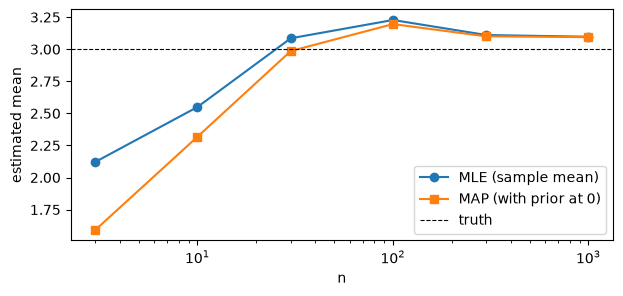

In [3]:
mles, maps = [], []
ns = [3, 10, 30, 100, 300, 1000]
for n in ns:
    x = rng.randn(n) * 2.0 + 3.0
    d = fit(x, GaussianEstimator(prior=NormalGammaDistribution(0.0, 1.0, 2.0, 2.0)))
    mles.append(x.mean())
    maps.append(d.mu)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ns, mles, 'o-', label='MLE (sample mean)')
ax.plot(ns, maps, 's-', label='MAP (with prior at 0)')
ax.axhline(3.0, color='k', ls='--', lw=0.8, label='truth')
ax.set_xscale('log'); ax.set_xlabel('n'); ax.set_ylabel('estimated mean'); ax.legend();

## 2. Categorical with a Dirichlet prior: mass for the unseen

A maximum-likelihood categorical assigns probability zero to anything it never saw. A Dirichlet prior fixes this - but there is a subtlety worth teaching: with a MAP estimate, the posterior mode of a Dirichlet with concentration $\alpha$ adds $\alpha - 1$ pseudo-counts per category. So $\alpha = 1$ (the flat prior) reproduces the MLE exactly, zeros included; smoothing requires $\alpha > 1$. (The posterior mean would add $\alpha$ instead - one of the classic MAP-vs-mean differences.) Note `'c'` appears in the prior but never in the data.


In [4]:
data = ['a'] * 60 + ['b'] * 40
prior = DictDirichletDistribution({'a': 2.0, 'b': 2.0, 'c': 2.0})
d = fit(data, CategoricalEstimator(prior=prior))

for v in ['a', 'b', 'c']:
    print('P(%s) = %.4f' % (v, np.exp(d.log_density(v))))

P(a) = 0.5922
P(b) = 0.3981
P(c) = 0.0097


## 3. The count family

The same pattern covers the discrete leaves - each has its textbook conjugate prior, each fits in one pass, and each fitted model carries its posterior:

| likelihood | parameter | conjugate prior |
|---|---|---|
| Poisson | rate $\lambda$ | Gamma$(a, b)$ |
| Geometric | success prob $p$ | Beta$(a, b)$ |
| Binomial | success prob $p$ | Beta$(a, b)$ |
| Exponential | rate $1/\beta$ | Gamma$(a, b)$ |


In [5]:
counts = PoissonDistribution(6.0).sampler(seed=13).sample(size=200)
d_pois = fit(counts, PoissonEstimator(prior=GammaDistribution(1.0, 1.0)))
print('Poisson:    true lambda 6.0, MAP %.3f' % d_pois.lam)

waits = GeometricDistribution(0.3).sampler(seed=14).sample(size=200)
d_geo = fit(waits, GeometricEstimator(prior=BetaDistribution(1.0, 1.0)))
print('Geometric:  true p 0.3,     MAP %.3f' % d_geo.p)

Poisson:    true lambda 6.0, MAP 5.761
Geometric:  true p 0.3,     MAP 0.313


## 4. Priors nest: combinators

This is where `bstats` pays off structurally. The combinators (`Composite`, `Sequence`, `Optional`, ...) compose priors along with likelihoods - a record model is built exactly like its `mixle.stats` counterpart, but every slot carries its own conjugate prior, and the joint prior term in the objective is the sum over the tree.

Below: records of the form `(value, label, token sequence)` - a Gaussian slot, a categorical slot, and a variable-length sequence slot with its own length model. One `fit` call updates every posterior in the tree.


In [6]:
truth = CompositeDistribution((
    GaussianDistribution(2.0, 1.0),
    CategoricalDistribution({'x': 0.7, 'y': 0.3}),
    SequenceDistribution(IntegerCategoricalDistribution(0, [0.5, 0.3, 0.2]),
                         len_dist=PoissonDistribution(4.0)),
))
data = truth.sampler(seed=7).sample(size=300)
print('a sample:', data[0])

est = CompositeEstimator((
    GaussianEstimator(),
    CategoricalEstimator(prior=DictDirichletDistribution({'x': 1.0, 'y': 1.0})),
    SequenceEstimator(IntegerCategoricalEstimator(), len_estimator=PoissonEstimator()),
))
d = fit(data, est)
print()
print(str(d))

a sample: (np.float64(2.0030451329784746), 'y', [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1)])

CompositeDistribution((GaussianDistribution(2.1204328519393285, 0.86301899666658, name=None, keys=None),CategoricalDistribution({'x': 0.66, 'y': 0.34}, default_value=0.0, name=None, keys=None),SequenceDistribution(IntegerCategoricalDistribution(0, [np.float64(0.4828711256117455), np.float64(0.3197389885807504), np.float64(0.19738988580750408)], name=None, keys=None), len_dist=PoissonDistribution(4.086666666666667, name=None, keys=None), len_normalized=False, name=None)))


## 5. Mixtures: MAP-EM with a penalized objective

Latent-variable models need iteration, and `bstats.optimize` runs EM on the penalized objective - log-likelihood plus the log prior over all parameters. The printout shows that combined objective increasing monotonically; convergence is declared on it, so the prior participates in the stopping rule, not just the updates. Priors matter most exactly here: mixture MLE is famously ill-posed (a component can collapse onto one point with $\sigma^2 \to 0$ and send the likelihood to $+\infty$), and the normal-gamma prior bounds that pathology away.


In [7]:
comps = [CompositeDistribution((GaussianDistribution(m, 1.0),
                               CategoricalDistribution(p)))
         for m, p in [(-6.0, {'x': 0.8, 'y': 0.2}),
                      (0.0,  {'x': 0.5, 'y': 0.5}),
                      (6.0,  {'x': 0.1, 'y': 0.9})]]
truth = MixtureDistribution(comps, [0.5, 0.3, 0.2])
data = truth.sampler(seed=3).sample(size=900)

comp_est = CompositeEstimator((
    GaussianEstimator(),
    CategoricalEstimator(prior=DictDirichletDistribution({'x': 1.0, 'y': 1.0})),
))
est = MixtureEstimator([comp_est] * 3)

mix = optimize(data, est, max_its=200, rng=np.random.RandomState(1), print_iter=50)
print()
# mixture components are exchangeable (label switching), so display sorted by weight
order = np.argsort(np.asarray(mix.w, dtype=float))[::-1]
print('fitted weights:', np.round(np.asarray(mix.w, dtype=float)[order], 3), ' (truth: 0.5, 0.3, 0.2)')
print('fitted means:  ', np.round([mix.components[k].dists[0].mu for k in order], 3), ' (truth: -6, 0, 6)')


fitted weights: [0.492 0.32  0.188]  (truth: 0.5, 0.3, 0.2)
fitted means:   [-6.02  -0.092  6.002]  (truth: -6, 0, 6)


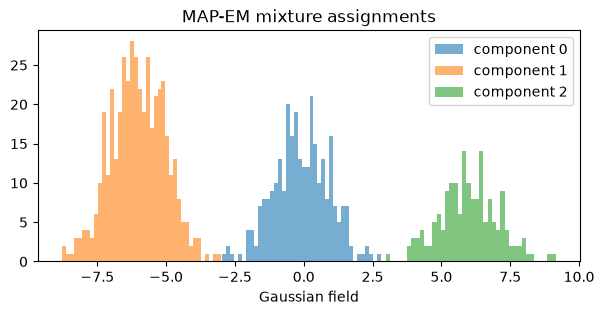

In [8]:
enc = mix.dist_to_encoder().seq_encode(data)
post = mix.seq_posterior(enc)
hard = np.argmax(post, axis=1)

fig, ax = plt.subplots(figsize=(7, 3))
vals = np.asarray([u[0] for u in data])
for k in range(3):
    ax.hist(vals[hard == k], bins=40, alpha=0.6, label='component %d' % k)
ax.set_xlabel('Gaussian field'); ax.legend(); ax.set_title('MAP-EM mixture assignments');

## 6. The Dirichlet process mixture: let the data choose $K$

The fixed-$K$ mixture above required us to say "3". The Dirichlet process mixture replaces the fixed weight vector with a stick-breaking prior: an infinite sequence of components whose weights $w_k = v_k \prod_{j<k}(1 - v_j)$ decay, truncated at some generous level for computation. Variational inference then maximizes the ELBO, and components the data don't need are simply starved of posterior mass - the model infers its complexity.

We hand it 15 sticks and data from 4 clusters, and count how many components survive.

A practical note: truncated variational DPs typically leave a few residual sticks with small but nonzero weight - the ELBO gains little by zeroing them exactly. The right reading is mass, not count: a handful of dominant components carry essentially all of the posterior weight, and that count is the model's answer for $K$. Variational inference also has local optima, so as with any EM-family method, restarts matter - `mixle.stats.bestimation` fits from a random initialization, and different seeds can land on solutions that split a cluster across two sticks.


In [9]:
true_comps = [CompositeDistribution((GaussianDistribution(m, 0.5),
                                     CategoricalDistribution(p)))
              for m, p in [(-9.0, {'x': 0.9, 'y': 0.1}), (-3.0, {'x': 0.6, 'y': 0.4}),
                           (3.0,  {'x': 0.3, 'y': 0.7}), (9.0,  {'x': 0.1, 'y': 0.9})]]
truth = MixtureDistribution(true_comps, [0.25] * 4)
data = truth.sampler(seed=11).sample(size=1200)

max_sticks = 15
comp_est = CompositeEstimator((
    GaussianEstimator(),
    CategoricalEstimator(prior=DictDirichletDistribution({'x': 1.0, 'y': 1.0})),
))
dpm_est = DirichletProcessMixtureEstimator([comp_est] * max_sticks)

dpm = optimize(data, dpm_est, max_its=400, rng=np.random.RandomState(4),
               print_iter=50)
w = np.asarray(dpm.w, dtype=float)
print()
ws = np.sort(w)[::-1]
print('stick weights:', np.round(ws[:8], 3), '...')
print('dominant components (w > 5%%): %d (truth: 4), carrying %.1f%% of the mass'
      % (int((w > 0.05).sum()), 100 * ws[:4].sum()))


stick weights: [0.27  0.256 0.238 0.223 0.004 0.003 0.001 0.001] ...
dominant components (w > 5%): 4 (truth: 4), carrying 98.8% of the mass


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_69643/1019921082.py:15: UserWarning: optimize() stopped at the max_its cap (400) before the objective settled (last objective gain 25, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  dpm = optimize(data, dpm_est, max_its=400, rng=np.random.RandomState(4),


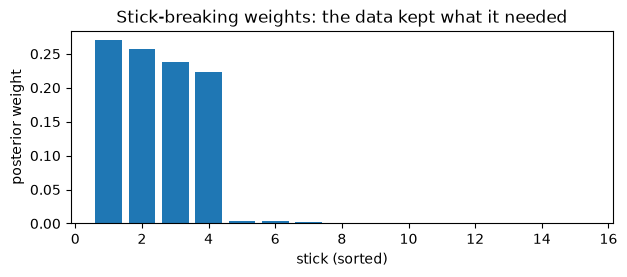

In [10]:
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.bar(range(1, max_sticks + 1), np.sort(w)[::-1])
ax.set_xlabel('stick (sorted)'); ax.set_ylabel('posterior weight')
ax.set_title('Stick-breaking weights: the data kept what it needed');

## 7. Everything at once: a DP mixture of nested heterogeneous records

The finale stacks the whole zoo. Each observation is a record

$$(\text{real value},\; \text{token sequence of random length},\; \text{maybe-missing count})$$

modeled by `Composite(Gaussian, Sequence(IntegerCategorical, len=Poisson), Optional(Poisson))`, and a Dirichlet process mixture sits on top to discover the group structure. Every leaf has a conjugate prior; the stick-breaking prior governs the number of groups; one `optimize` call fits the entire hierarchy by variational inference.


In [11]:
def make_group(mu, pvec, lam, miss_p):
    return CompositeDistribution((
        GaussianDistribution(mu, 1.0),
        SequenceDistribution(IntegerCategoricalDistribution(0, list(pvec)),
                             len_dist=PoissonDistribution(5.0)),
        OptionalDistribution(PoissonDistribution(lam), p=miss_p),
    ))

g_rng = np.random.RandomState(5)
groups = [make_group(-6.0, [0.7, 0.2, 0.05, 0.05], 2.0, 0.1),
          make_group(0.0,  [0.05, 0.7, 0.2, 0.05], 8.0, 0.3),
          make_group(6.0,  [0.05, 0.05, 0.2, 0.7], 20.0, 0.05)]
truth = MixtureDistribution(groups, [0.4, 0.35, 0.25])
data = truth.sampler(seed=21).sample(size=900)
print('two samples:')
print(' ', data[0])
print(' ', data[1])

two samples:
  (np.float64(-6.843131758409815), [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1)], np.int64(1))
  (np.float64(-6.0590554191352695), [np.int64(0), np.int64(0), np.int64(0), np.int64(0)], np.int64(2))


In [12]:
comp_est = CompositeEstimator((
    GaussianEstimator(prior=NormalGammaDistribution(0.0, 1.0, 2.0, 2.0)),
    SequenceEstimator(IntegerCategoricalEstimator(prior=DirichletDistribution([1.0, 1.0, 1.0, 1.0])),
                      len_estimator=PoissonEstimator(prior=GammaDistribution(1.0, 1.0))),
    OptionalEstimator(PoissonEstimator(prior=GammaDistribution(1.0, 1.0))),
))
dpm_est = DirichletProcessMixtureEstimator([comp_est] * 12)

dpm = optimize(data, dpm_est, max_its=400, rng=np.random.RandomState(5), print_iter=50)
w = np.asarray(dpm.w, dtype=float)
print()
ws = np.sort(w)[::-1]
print('dominant components (w > 5%%): %d (simulator used 3)' % int((w > 0.05).sum()))
print('weights:', np.round(ws[:5], 3), ' (simulator: 0.40, 0.35, 0.25)')


dominant components (w > 5%): 3 (simulator used 3)
weights: [0.399 0.35  0.251 0.    0.   ]  (simulator: 0.40, 0.35, 0.25)


Look closely at the weights: the model reports four dominant components where the simulator used three - the middle group (the one where 30% of count fields are missing) is split into a "count present" and a "count missing" pair whose weights sum to the simulator's 0.35. This is worth internalizing: the DP answers "how many components does the data support under this likelihood?", not "how many did the generator use?" - missingness is itself structure, and the model found it.

To see the discovered structure, compute each record's posterior over the surviving components and color the Gaussian field by the hard assignment. The posterior is the component log-densities plus the stick weights, softmaxed - the same quantity `mixle.utils.hvis` uses to build model-based embeddings of data exactly like this.


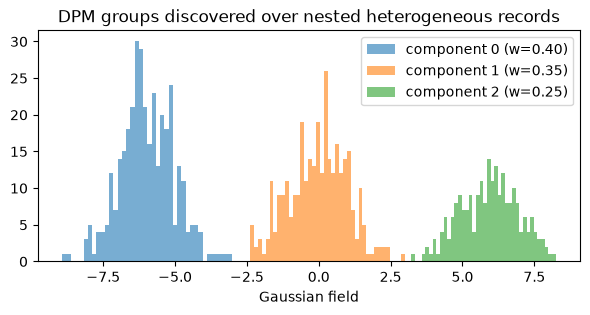

In [13]:
enc = dpm.dist_to_encoder().seq_encode(data)
ll = np.asarray([c.seq_log_density(enc) for c in dpm.components]).T + dpm.log_w
ll -= ll.max(axis=1, keepdims=True)
post = np.exp(ll); post /= post.sum(axis=1, keepdims=True)
hard = np.argmax(post, axis=1)

vals = np.asarray([u[0] for u in data])
live = [k for k in range(len(w)) if (hard == k).sum() > 0]
fig, ax = plt.subplots(figsize=(7, 3))
for k in live:
    ax.hist(vals[hard == k], bins=40, alpha=0.6, label='component %d (w=%.2f)' % (k, w[k]))
ax.set_xlabel('Gaussian field'); ax.legend()
ax.set_title('DPM groups discovered over nested heterogeneous records');

## 8. The Dirichlet process via stick-breaking

The nonparametric prior behind the DP mixture has a concrete constructive form - stick-breaking (Sethuraman 1994): break a unit stick by $\beta_k\sim\mathrm{Beta}(1,\alpha)$ and assign the broken piece to a random atom. The concentration $\alpha$ controls how many atoms carry appreciable mass, and the expected number of occupied clusters in $N$ draws grows like $\alpha\log N$. We construct it and verify that growth law.


In [14]:
def stick_breaking(alpha, trunc=300, seed=0):
    r = np.random.RandomState(seed); betas = r.beta(1.0, alpha, trunc)
    w = betas * np.concatenate([[1.0], np.cumprod(1 - betas)[:-1]])
    return w / w.sum()
for alpha in [0.5, 2.0, 8.0]:
    w = stick_breaking(alpha); k90 = int(np.searchsorted(np.cumsum(np.sort(w)[::-1]), 0.90) + 1)
    print('alpha=%.1f -> %d atoms hold 90%% of the mass' % (alpha, k90))
# E[#clusters] ~ alpha * log(N): draw cluster labels and count occupied
def occupied(alpha, N, seed):
    w = stick_breaking(alpha, seed=seed)
    return len(set(np.random.RandomState(seed + 1).choice(len(w), size=N, p=w)))
for alpha in [1.0, 4.0]:
    emp = np.mean([occupied(alpha, 1000, s) for s in range(20)])
    print('alpha=%.1f, N=1000: occupied clusters ~ %.1f   alpha*log(N)=%.1f' % (alpha, emp, alpha * np.log(1000)))

alpha=0.5 -> 3 atoms hold 90% of the mass
alpha=2.0 -> 6 atoms hold 90% of the mass
alpha=8.0 -> 16 atoms hold 90% of the mass
alpha=1.0, N=1000: occupied clusters ~ 7.8   alpha*log(N)=6.9
alpha=4.0, N=1000: occupied clusters ~ 22.8   alpha*log(N)=27.6


## Illustration: the Dirichlet process grows clusters like alpha*log(n)

We simulate the Chinese restaurant process and count occupied tables as customers arrive, comparing the
empirical cluster count to the exact expectation $\sum_i \alpha/(\alpha+i-1)$ and its $\alpha\log n$
approximation. The concentration parameter $\alpha$ sets the growth rate.

In [15]:
rng = np.random.RandomState(0)
def crp_tables(n, alpha):
    counts = []
    for i in range(n):
        probs = np.array(counts + [alpha], float); probs /= probs.sum()
        j = rng.choice(len(probs), p=probs)
        if j == len(counts): counts.append(1)
        else: counts[j] += 1
    return len(counts)
print(' alpha      n      mean #clusters (sim)    exact E[K_n]      alpha*log(n)')
for alpha in [1.0, 3.0]:
    for n in [100, 1000]:
        sim = np.mean([crp_tables(n, alpha) for _ in range(200)])
        exact = np.sum(alpha / (alpha + np.arange(n)))
        print('  %.1f    %5d        %6.1f              %6.1f            %6.1f' %
              (alpha, n, sim, exact, alpha * np.log(n)))
print('the occupied-table count tracks the exact sum and grows logarithmically, scaled by alpha.')

 alpha      n      mean #clusters (sim)    exact E[K_n]      alpha*log(n)


  1.0      100           5.1                 5.2               4.6


  1.0     1000           7.9                 7.5               6.9


  3.0      100          10.8                11.1              13.8


  3.0     1000          18.2                18.0              20.7
the occupied-table count tracks the exact sum and grows logarithmically, scaled by alpha.


## References

- Diaconis, P. & Ylvisaker, D. (1979). Conjugate priors for exponential families (https://doi.org/10.1214/aos/1176344611). Ann. Statist. 7(2), 269-281.
- Ferguson, T. S. (1973). A Bayesian analysis of some nonparametric problems (https://doi.org/10.1214/aos/1176342360). Ann. Statist. 1(2), 209-230. - the Dirichlet process.
- Sethuraman, J. (1994). A constructive definition of Dirichlet priors (https://www.jstor.org/stable/24305538). Statistica Sinica 4, 639-650. - stick-breaking.
- Neal, R. M. (2000). Markov chain sampling methods for Dirichlet process mixture models (https://doi.org/10.1080/10618600.2000.10474879). JCGS 9(2), 249-265.
- Teh, Y. W., Jordan, M. I., Beal, M. J. & Blei, D. M. (2006). Hierarchical Dirichlet processes (https://doi.org/10.1198/016214506000000302). JASA 101, 1566-1581.
- Gelman, A. et al. (2013). Bayesian Data Analysis (http://www.stat.columbia.edu/~gelman/book/), 3rd ed. CRC Press.


## Exercises and extensions

1. Stick-breaking from scratch. Implement the Sethuraman (1994) stick-breaking construction of a Dirichlet process, draw random measures at several concentrations $\alpha$, and visualize how $\alpha$ controls the number and size of atoms. Verify the $\mathbb E[\#\text{clusters}]\approx\alpha\log N$ growth empirically.
2. Collapsed Gibbs vs variational DP mixture. Implement Neal's (2000) collapsed Gibbs sampler for a DP mixture and compare its inferred clustering and number of components to mixle's (variational) DP mixture on the same data, by ARI and runtime. Discuss the exploration/speed trade-off.
3. Prior strength as regularization. For the Normal-Gamma example, quantify shrinkage vs $n$: show the MAP mean is the precision-weighted average and that the prior's influence decays like $\lambda_0/(\lambda_0+n)$; design a small-sample setting where the prior demonstrably reduces predictive error.
4. Pitman-Yor power-law tails. Replace the DP with a Pitman-Yor process (add a discount parameter) and show it produces the power-law cluster-size distribution seen in natural language / network data, which the DP cannot. Compare on a heavy-tailed clustering problem.
